# FAPE, Fairness Drift Detection and Deployment Monitoring

Phase 4, Stage 4: CUSUM-based fairness drift detection. The script simulates post-deployment monitoring with three versions of each domain and model: v1 the baseline, v2 the constrained model that gets deployed, and v3 a synthetic distribution shift. A one-sided CUSUM monitor starts when v2 is deployed and watches the 0.1 demographic parity difference research convention. The v3 shift moves each model linearly from its post-constraint DPD toward a point 60% of the way back to its baseline DPD, so the size of each regression is fixed by construction at a share of that model's correction. The stage shows that the monitor catches such a regression; it does not show that large corrections are empirically more fragile, and no production drift was observed (Decision 7). The baseline model is never deployed, so v1 observations are shown but never monitored. An alert in the v2 window means the constrained model was already above 0.1 when it went live, which is a different finding from drift in v3. All values come from `threshold_aggregation.RESULTS` and `MEPS_RESULTS`, and models a domain did not evaluate under the intervention (random forest for Law School, Lending Club and Agricultural) are excluded rather than filled with placeholders. Domains: COMPAS, Folktables, Law School, Lending Club, Agricultural, FairGround, MEPS and Student.

Code: `src/fairness_drift_monitor.py`. This notebook runs that script, so its printed output and figures are the ones the paper uses.

In [1]:
import os, sys, warnings, logging

# The data loaders read paths relative to the repository root (data/raw/...), so run from there.
# The check stops a second run of this cell from moving up another directory.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
if os.path.abspath('src') not in sys.path:
    sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
from IPython.display import Image, display

# matplotlib 3.8.4 (pinned) imports backend2gui from IPython when a script makes its first figure
# inside a kernel, and IPython 9 removed it. An empty mapping is what IPython 8 gave for Agg.
import IPython.core.pylabtools
if not hasattr(IPython.core.pylabtools, 'backend2gui'):
    IPython.core.pylabtools.backend2gui = {}

In [2]:
from fairness_drift_monitor import run_fairness_drift_monitor

run_fairness_drift_monitor()

FAPE Phase 4, Stage 4: Fairness Drift Detection

--- Simulating Distribution Shift ---
  COMPAS        first alert: LR=10(deployment)  RF=10(deployment)  GB=10(deployment)
  Folktables    first alert: LR=10(deployment)  RF=11(deployment)  GB=10(deployment)
  Law School    first alert: LR=28(shift)  RF=n/e  GB=27(shift)
  Lending Club  first alert: LR=-(none)  RF=n/e  GB=-(none)
  Agricultural  first alert: LR=-(none)  RF=n/e  GB=-(none)
  FairGround    first alert: LR=28(shift)  RF=28(shift)  GB=27(shift)
  MEPS          first alert: LR=-(none)  RF=10(deployment)  GB=-(none)
  Student       first alert: LR=-(none)  RF=10(deployment)  GB=10(deployment)


  Fig 1 saved, drift_dpd_timeseries.png


  Fig 2 saved, drift_cusum_scores.png


  Fig 3 saved, drift_alert_heatmap.png


  Fig 4 saved, drift_model_versioning.png


  Fig 5 saved, drift_first_alert_time.png


  Fig 6 saved, drift_acc_fairness_trajectory.png


  Fig 7 saved, drift_eod_timeseries.png
  Fig 8 saved - drift_magnitude_heatmap.png


  Fig 9 saved - drift_eod_magnitude_heatmap.png

--- Stage 4 Drift Detection complete ---
  9 figures saved to figures/stage2/
  Above DPD 0.1 at deployment (9): COMPAS LR, COMPAS RF, COMPAS GB, Folktables LR, Folktables RF, Folktables GB, MEPS RF, Student RF, Student GB
  Regression flagged under shift (5): Law School LR, Law School GB, FairGround LR, FairGround RF, FairGround GB
  Never flagged (7): Lending Club LR, Lending Club GB, Agricultural LR, Agricultural GB, MEPS LR, MEPS GB, Student LR
  Shift is synthetic and sized as a share of each correction (Decision 7)


## 1. Simulated DPD over time, gradient boosting

Simulated demographic parity difference across the baseline, deployed and shifted versions for each domain.

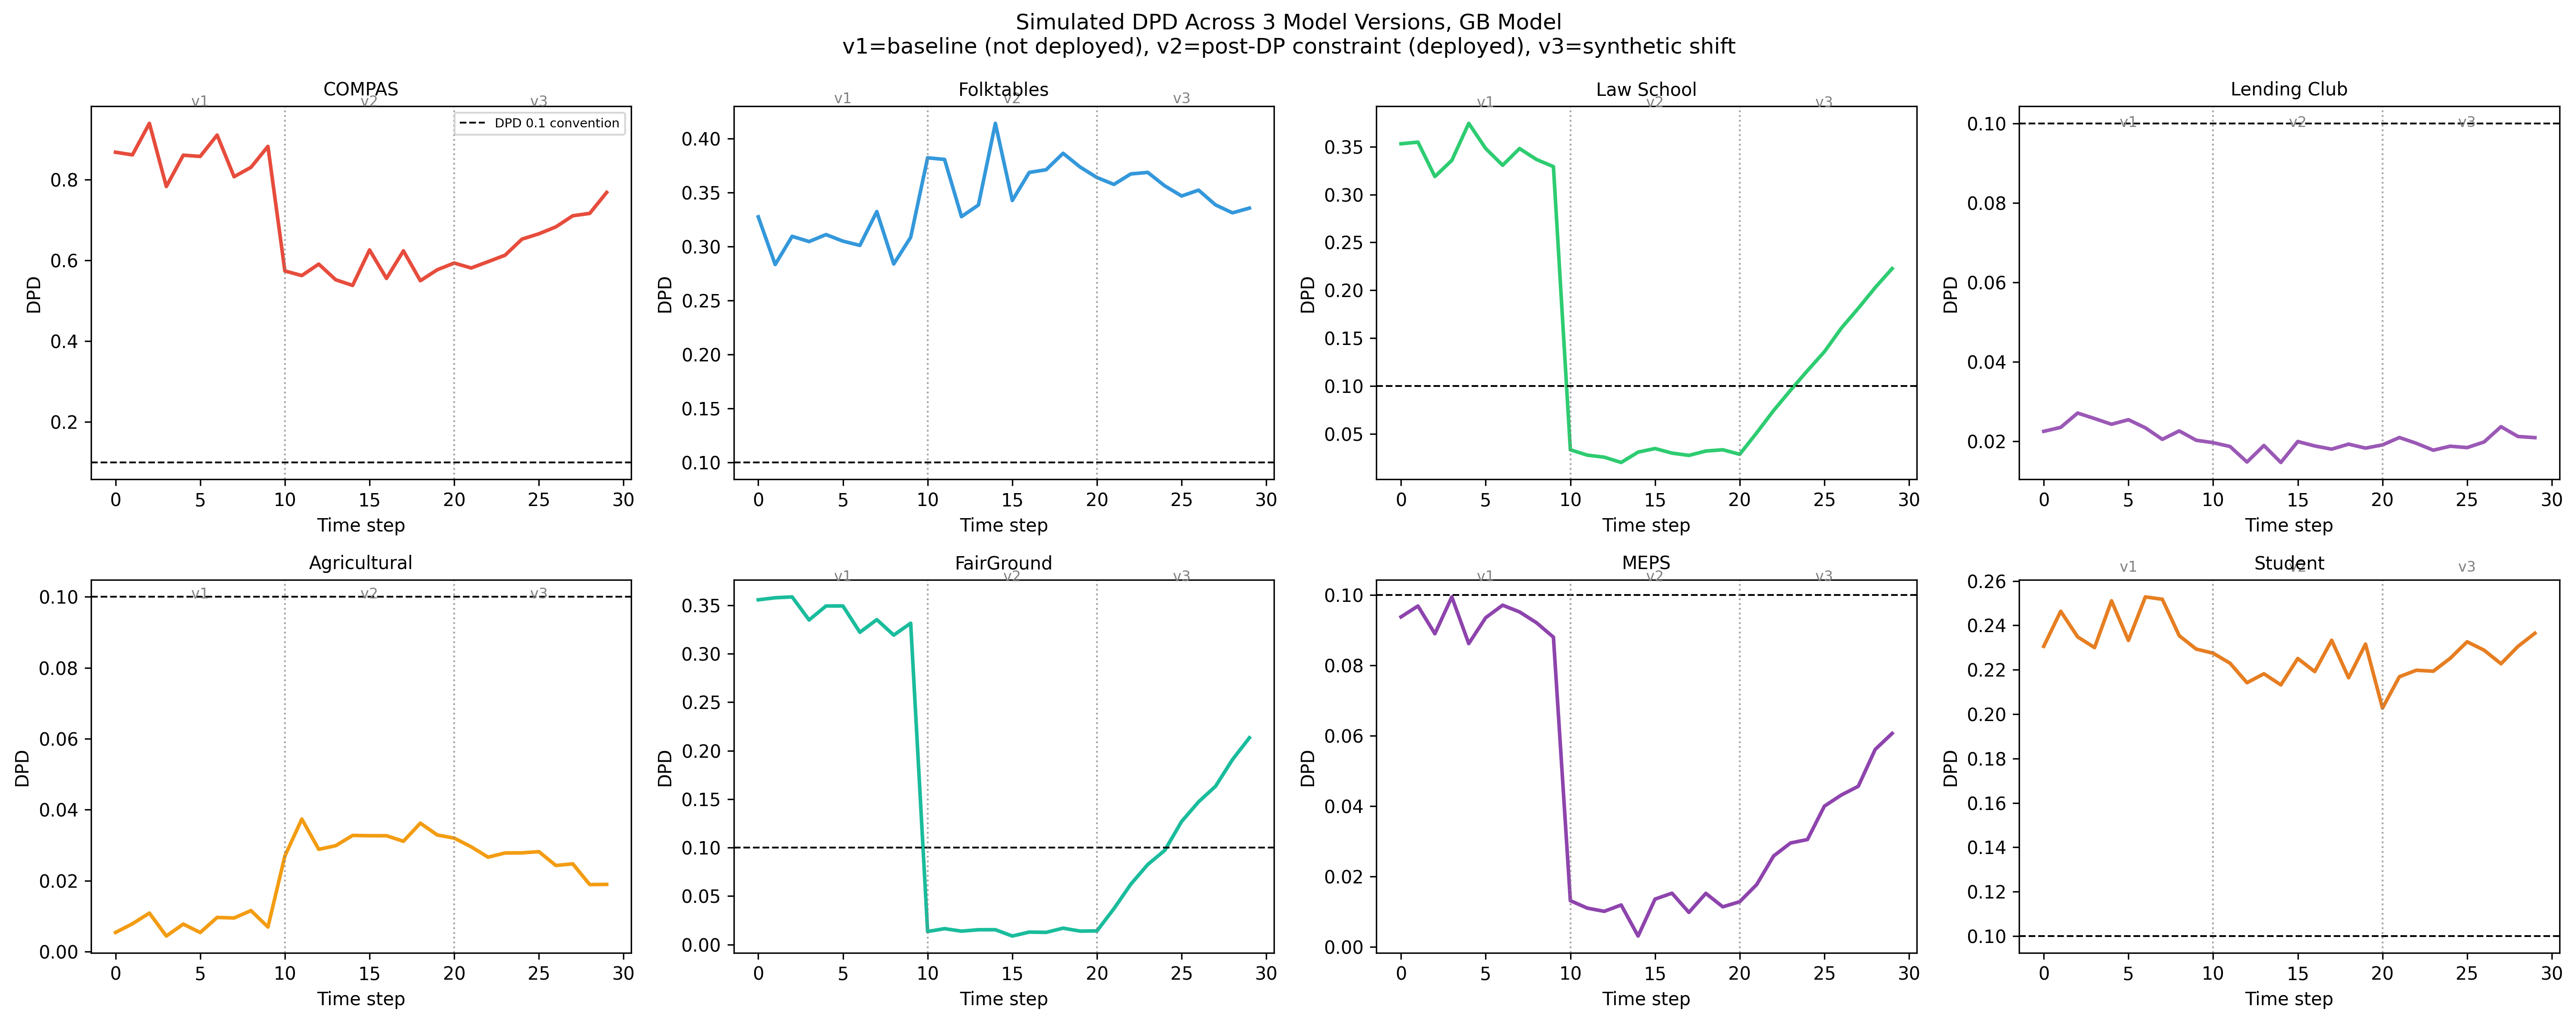

In [3]:
display(Image('figures/stage2/drift_dpd_timeseries.png'))

## 2. CUSUM scores after deployment, gradient boosting

The CUSUM score from deployment onward for each domain, with the first alert marked where one fires.

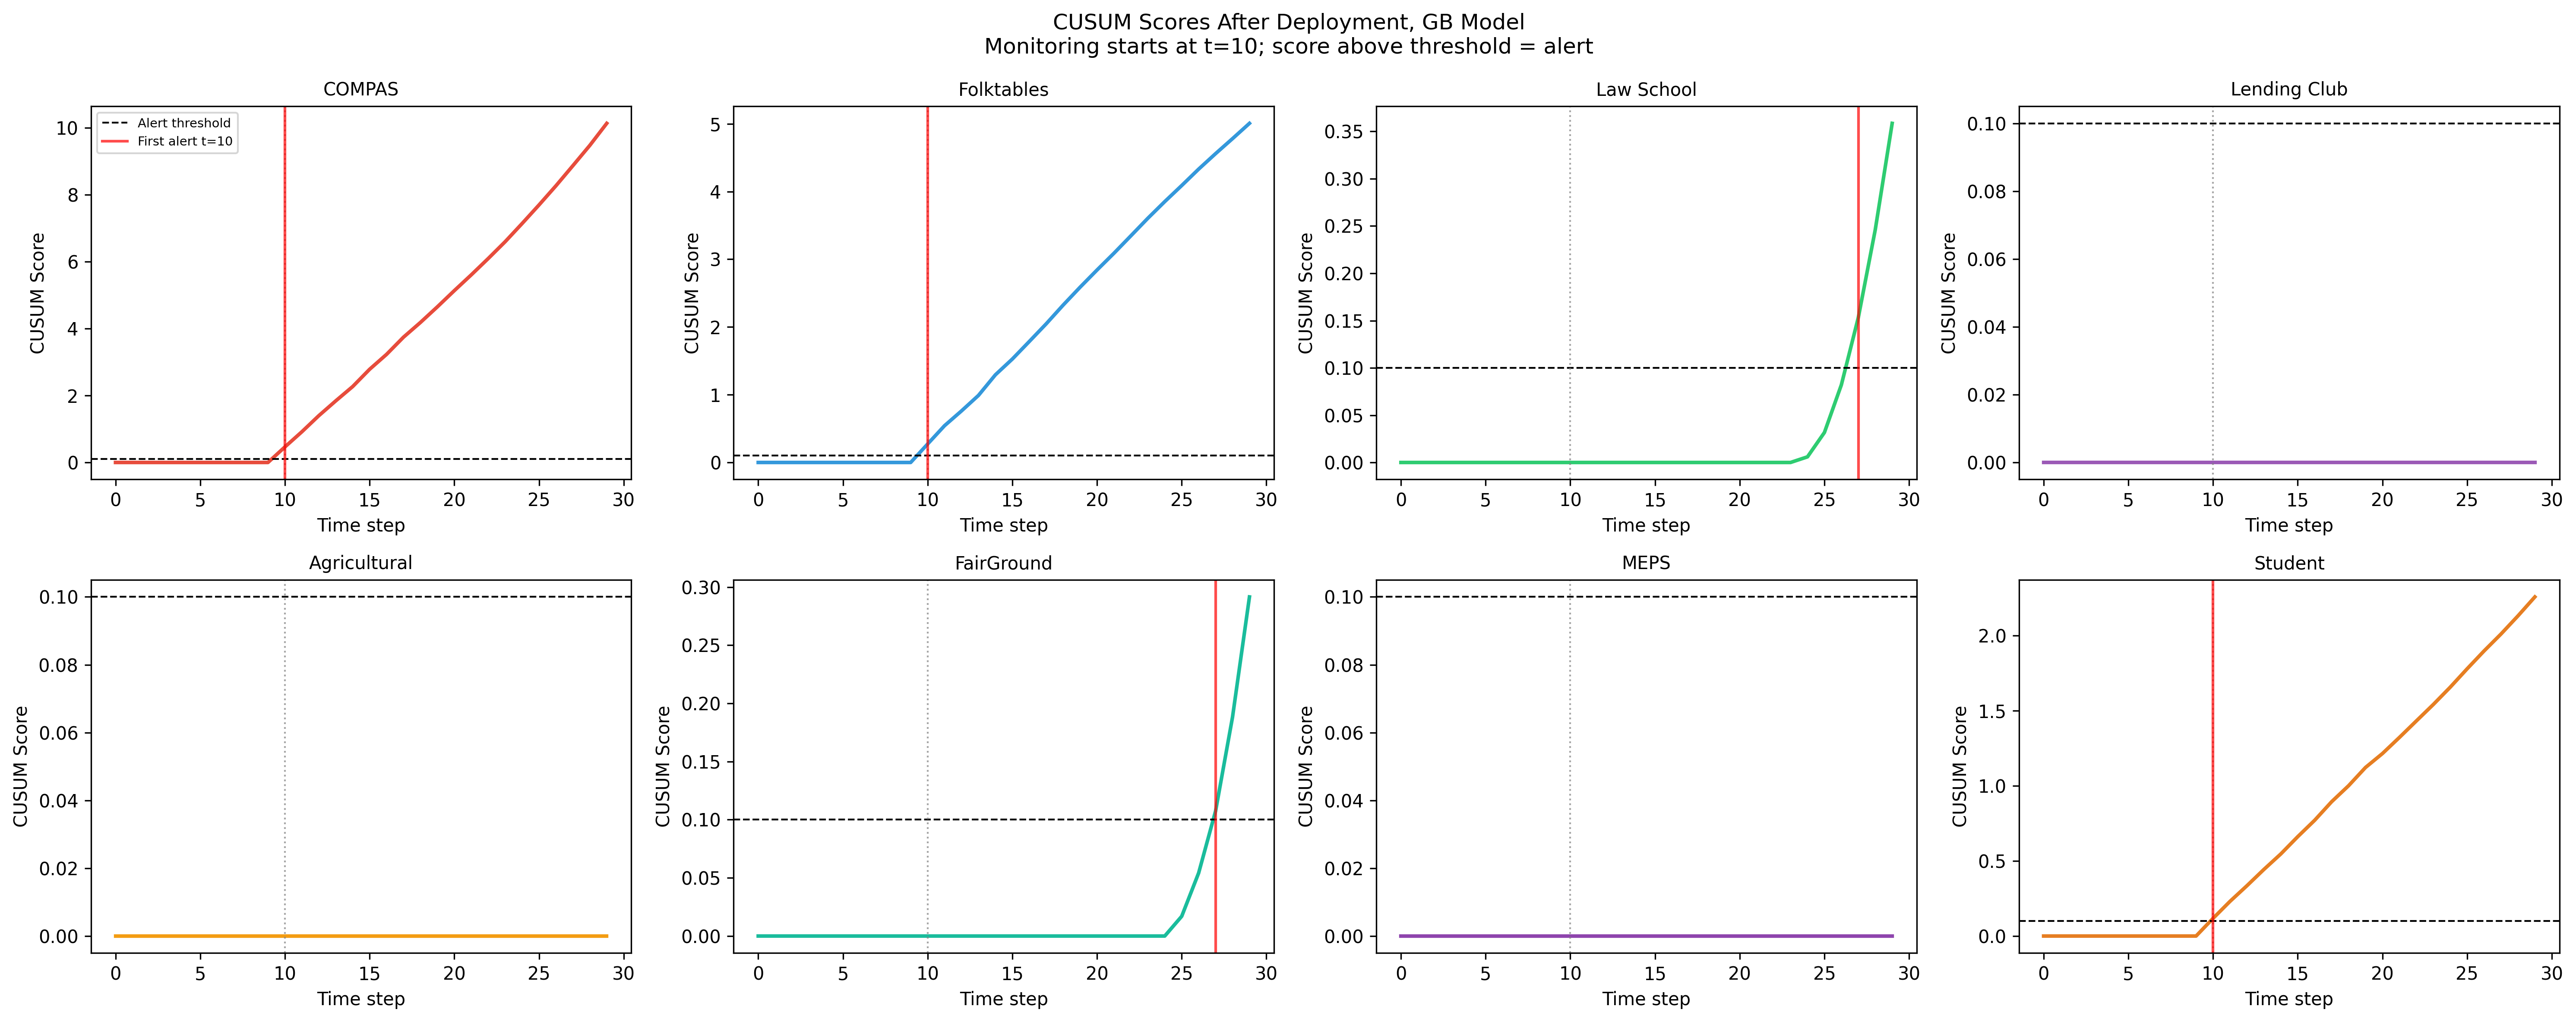

In [4]:
display(Image('figures/stage2/drift_cusum_scores.png'))

## 3. Alert counts by model and domain

Number of CUSUM alerts after deployment for each model and domain.

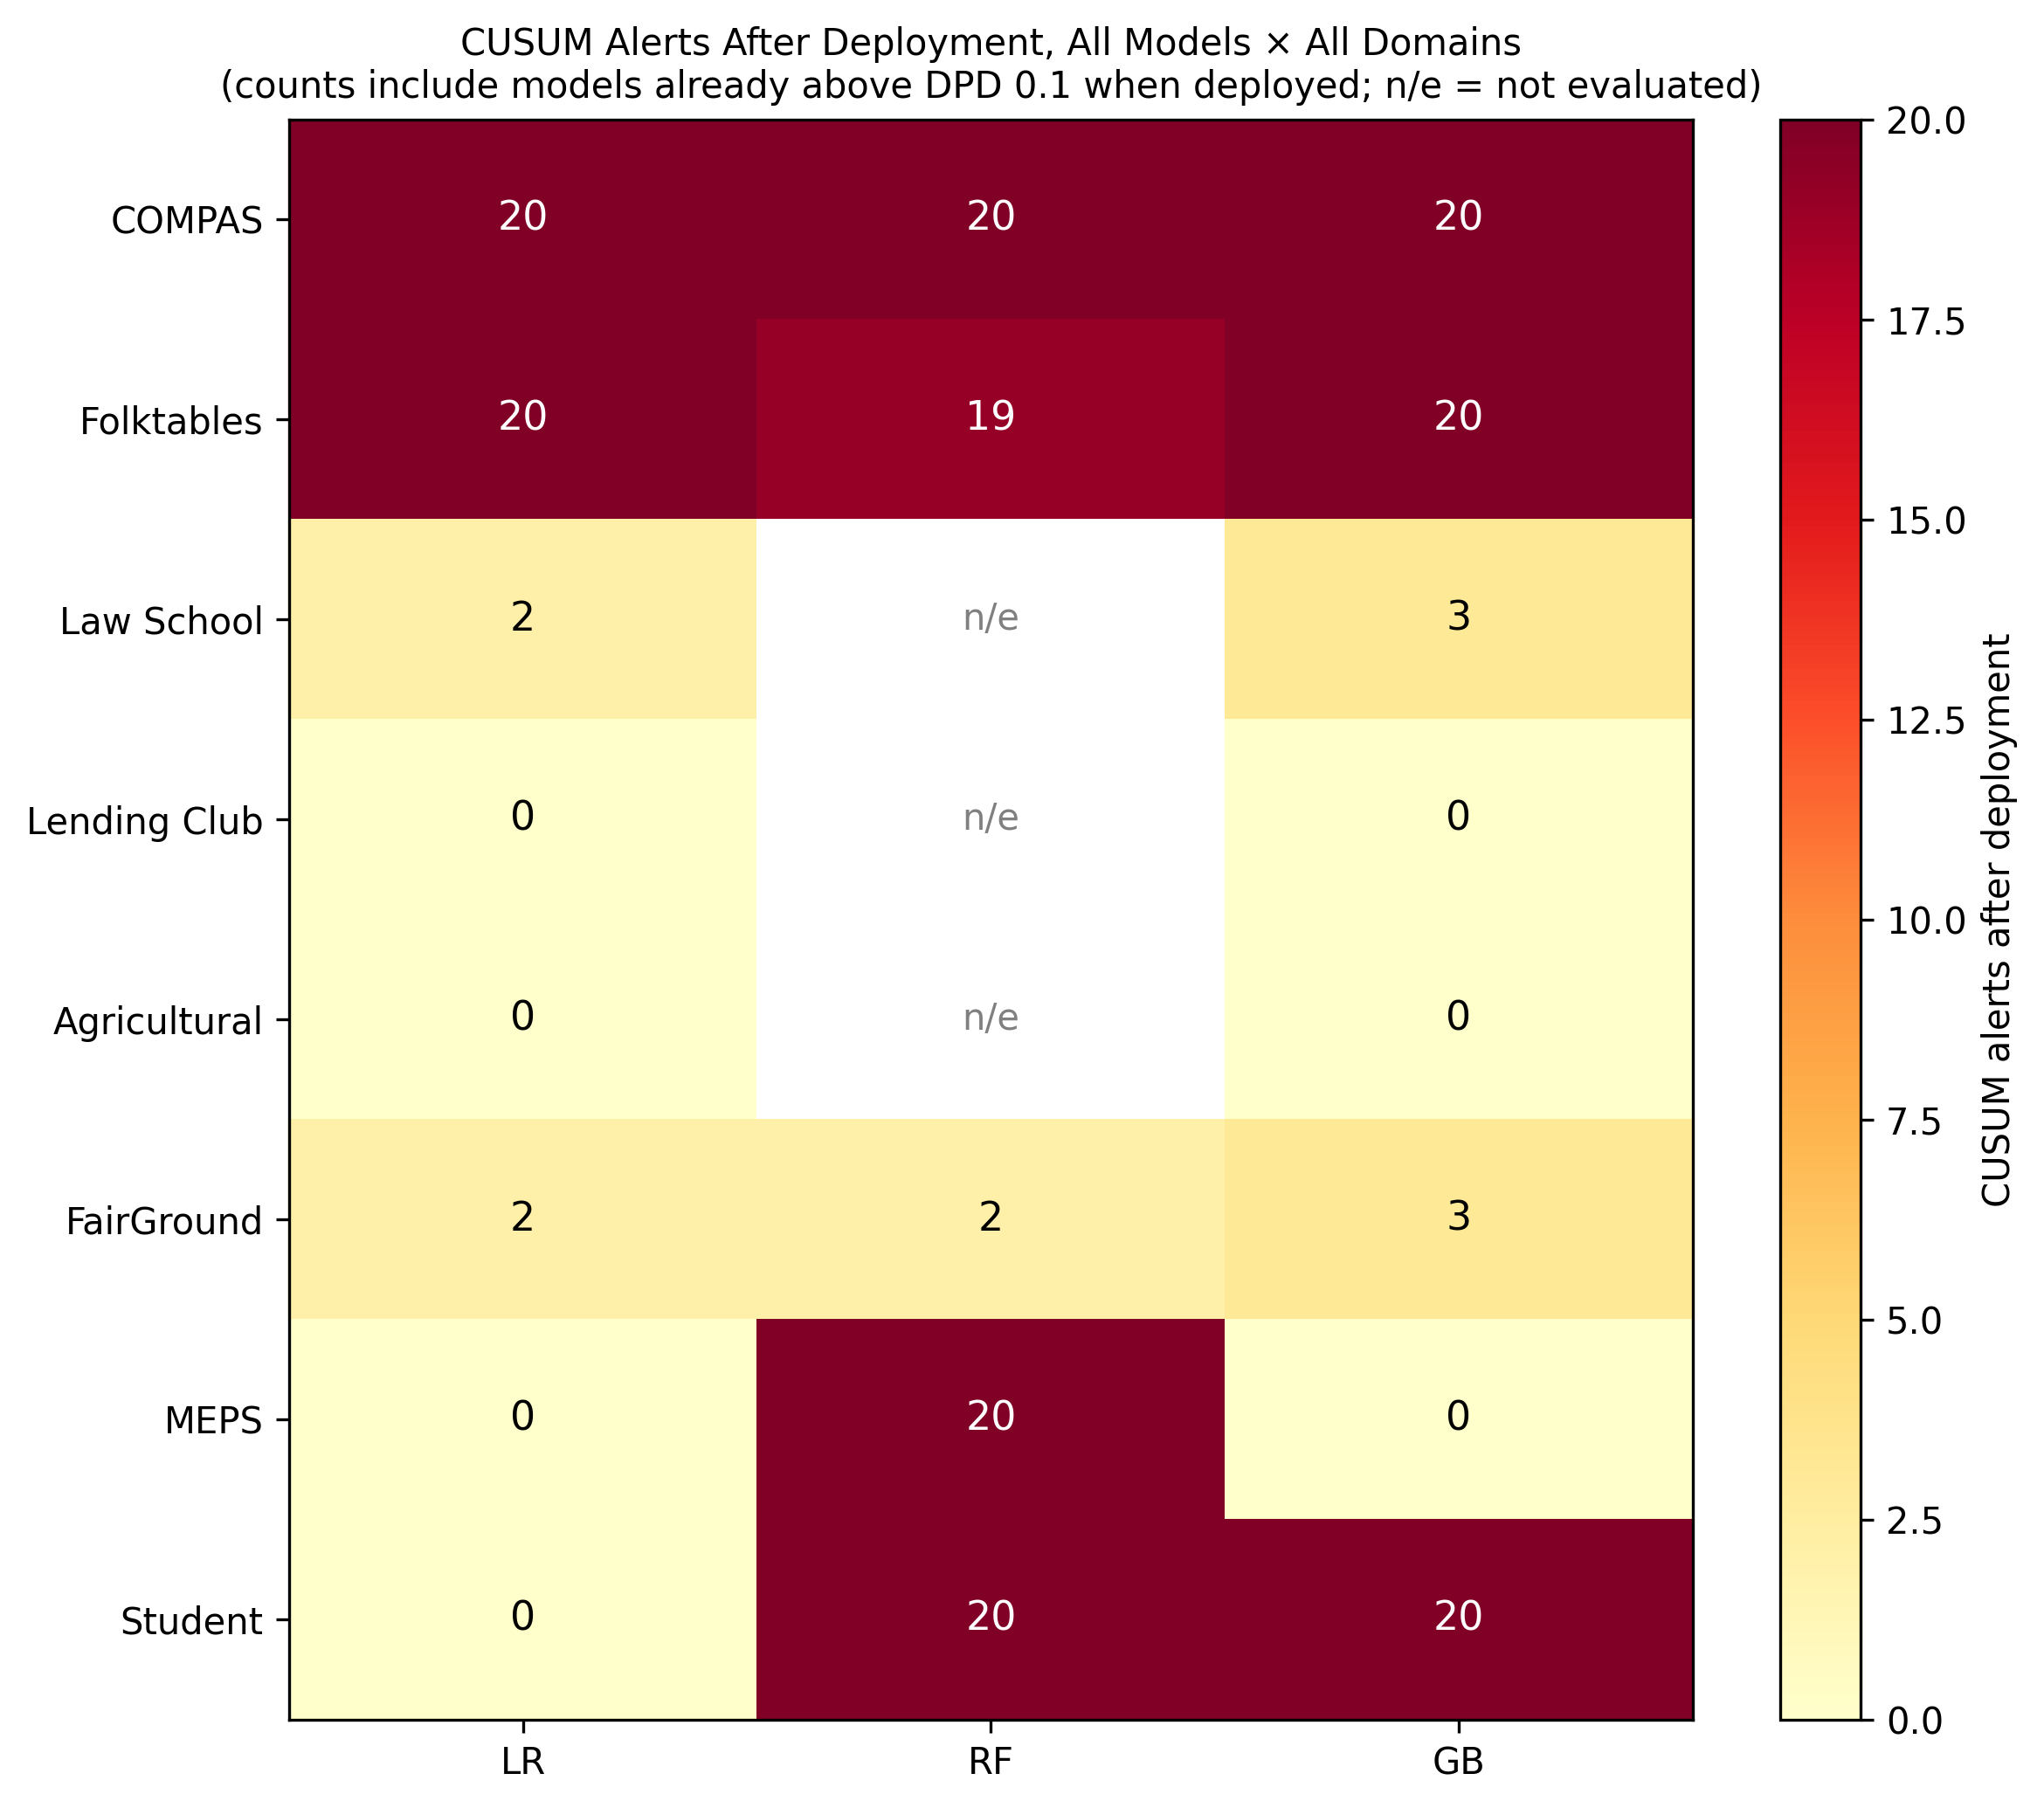

In [5]:
display(Image('figures/stage2/drift_alert_heatmap.png'))

## 4. DPD by model version

Baseline, post-constraint and mean shifted DPD for each model and domain.

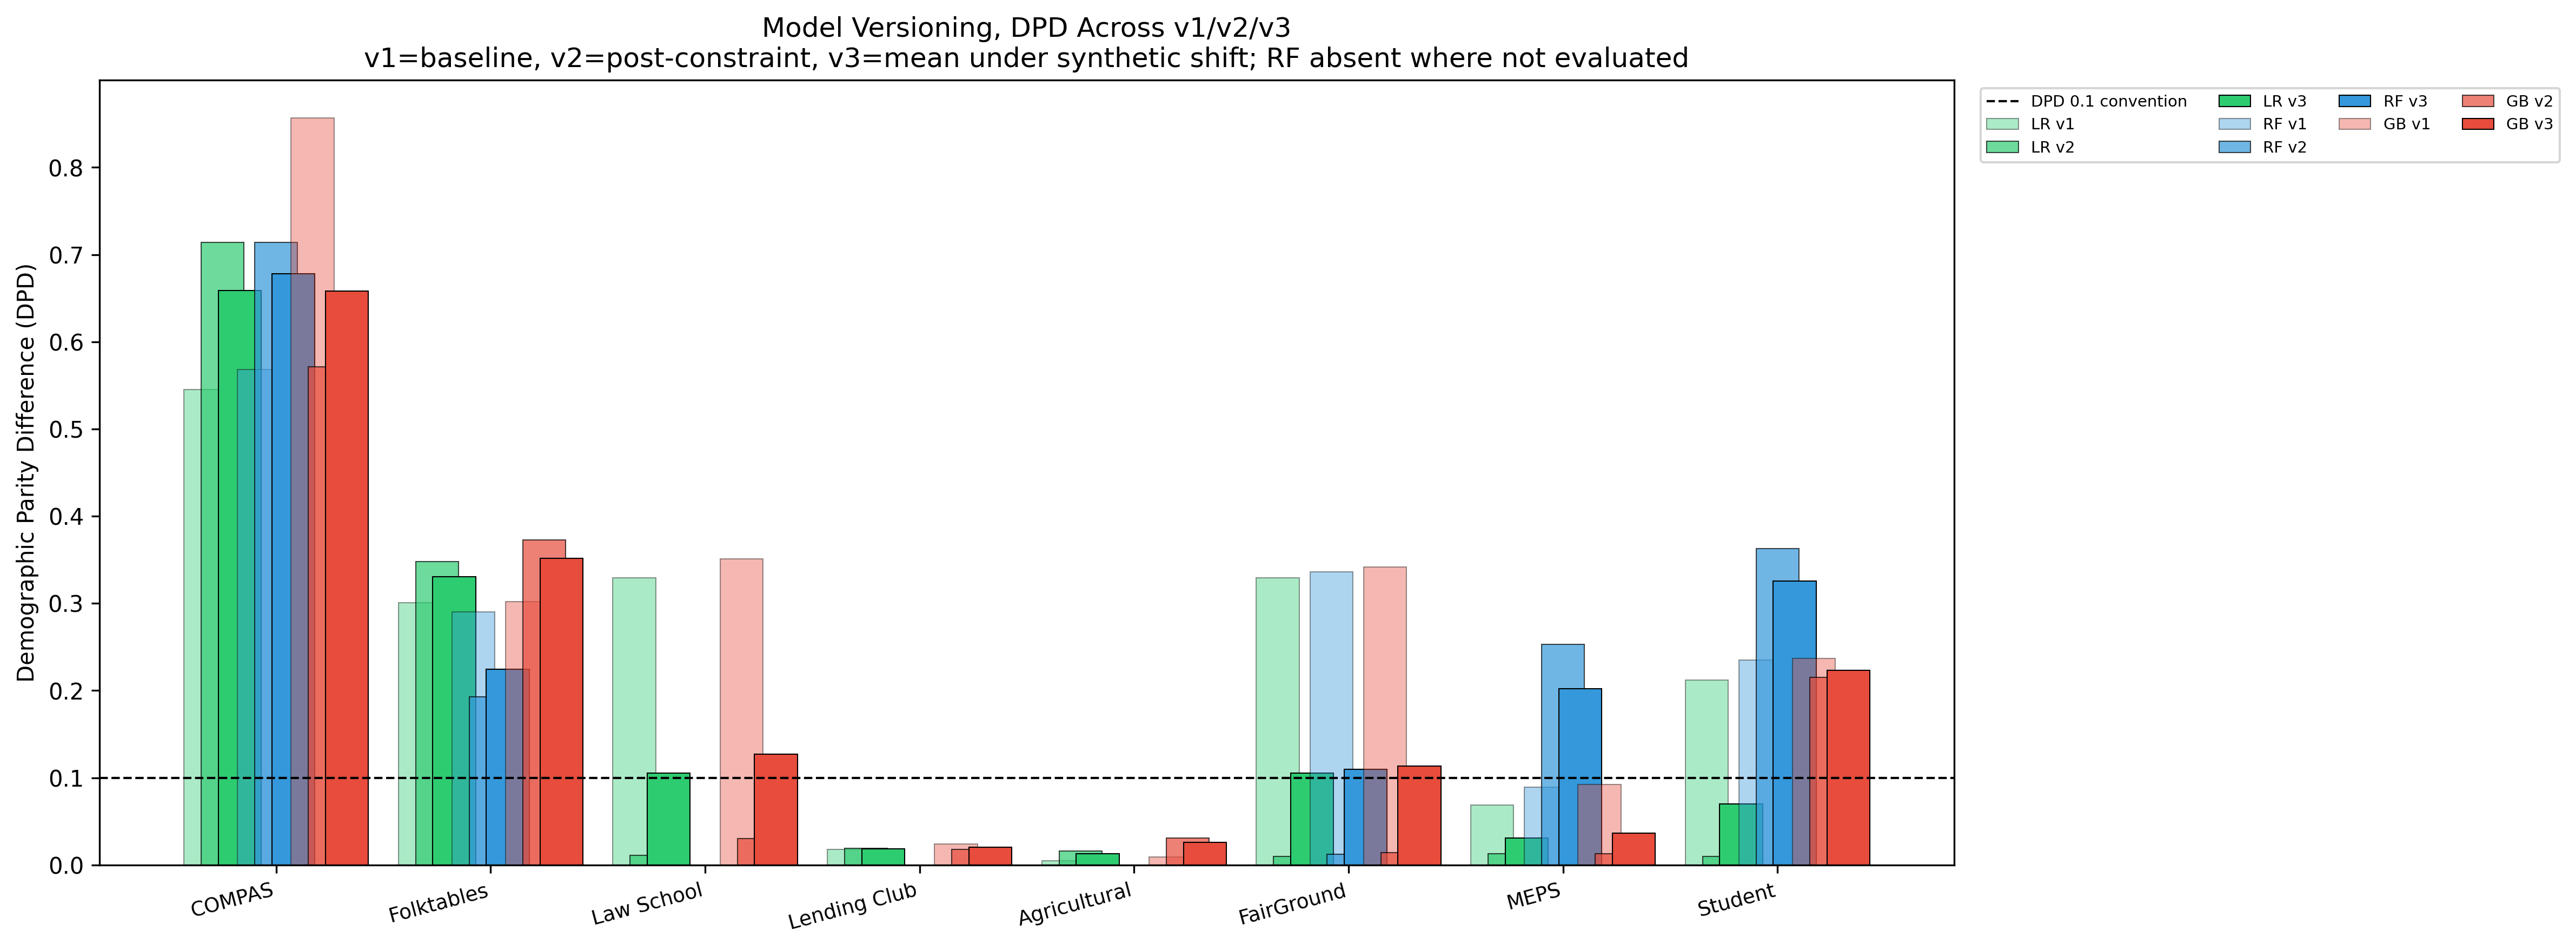

In [6]:
display(Image('figures/stage2/drift_model_versioning.png'))

## 5. Time of first alert

The time step of each model's first CUSUM alert after deployment, by domain.

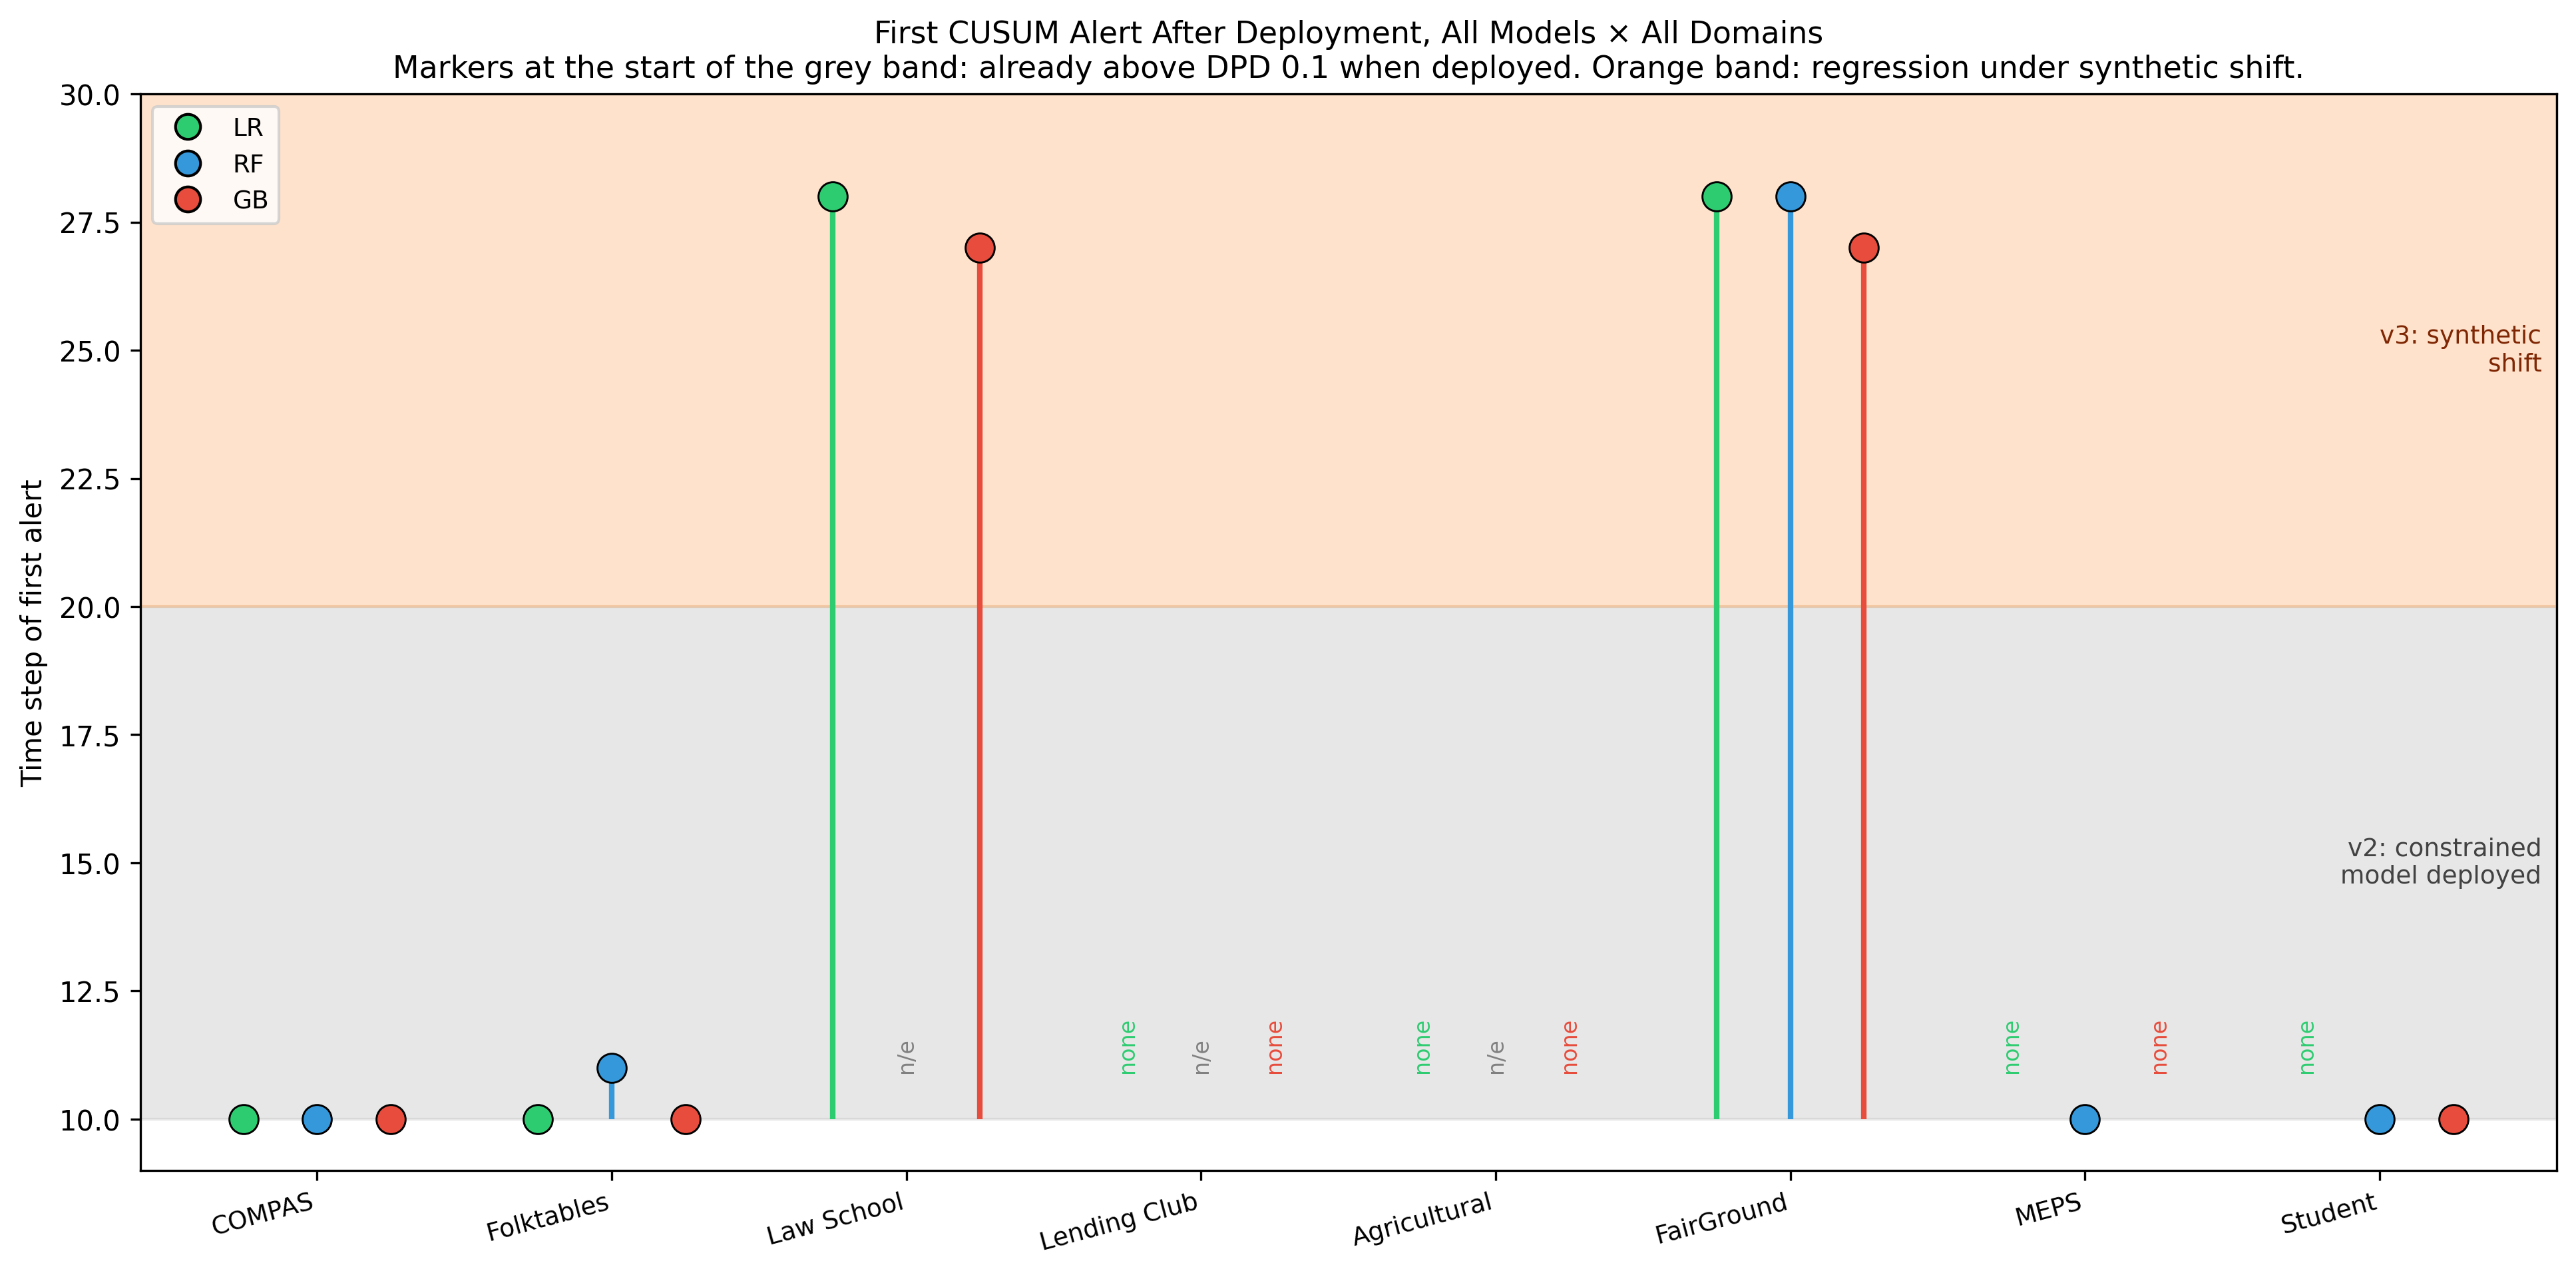

In [7]:
display(Image('figures/stage2/drift_first_alert_time.png'))

## 6. Accuracy-fairness trajectory, gradient boosting

Accuracy against DPD for each domain across the baseline, deployed and shifted versions.

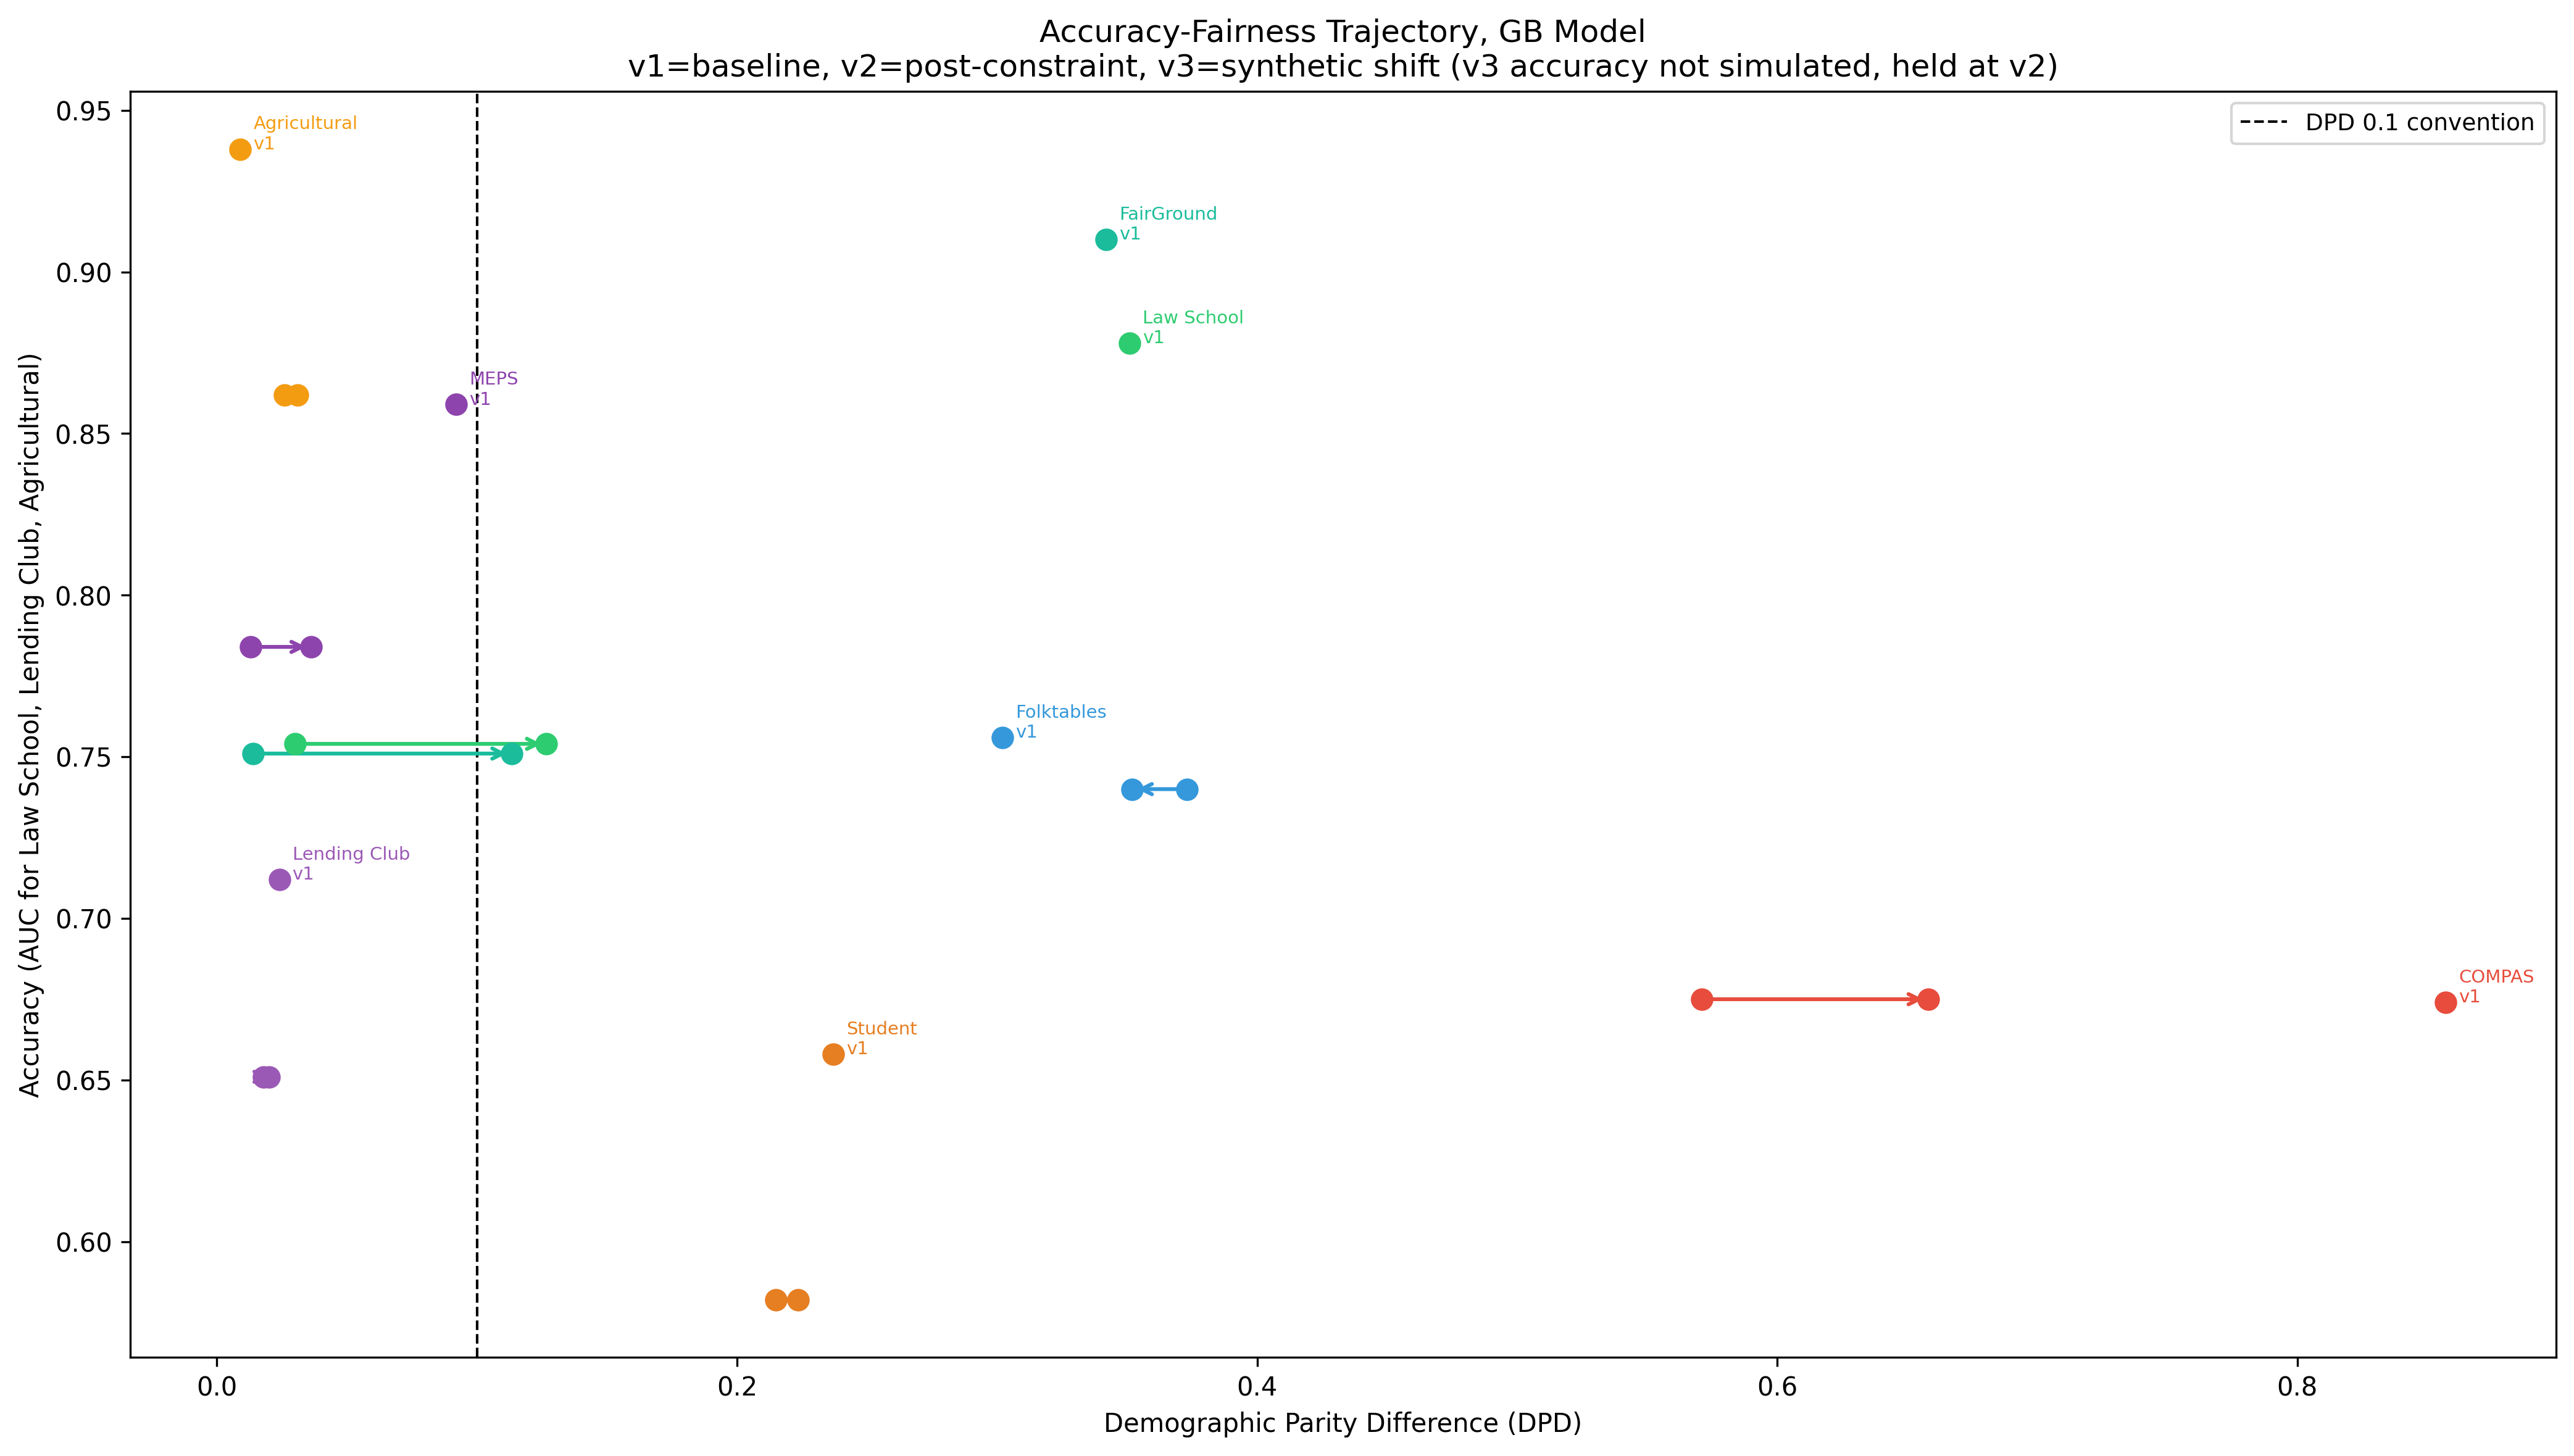

In [8]:
display(Image('figures/stage2/drift_acc_fairness_trajectory.png'))

## 7. Simulated EOD over time, gradient boosting

Simulated equalized odds difference across the baseline, deployed and shifted versions for each domain.

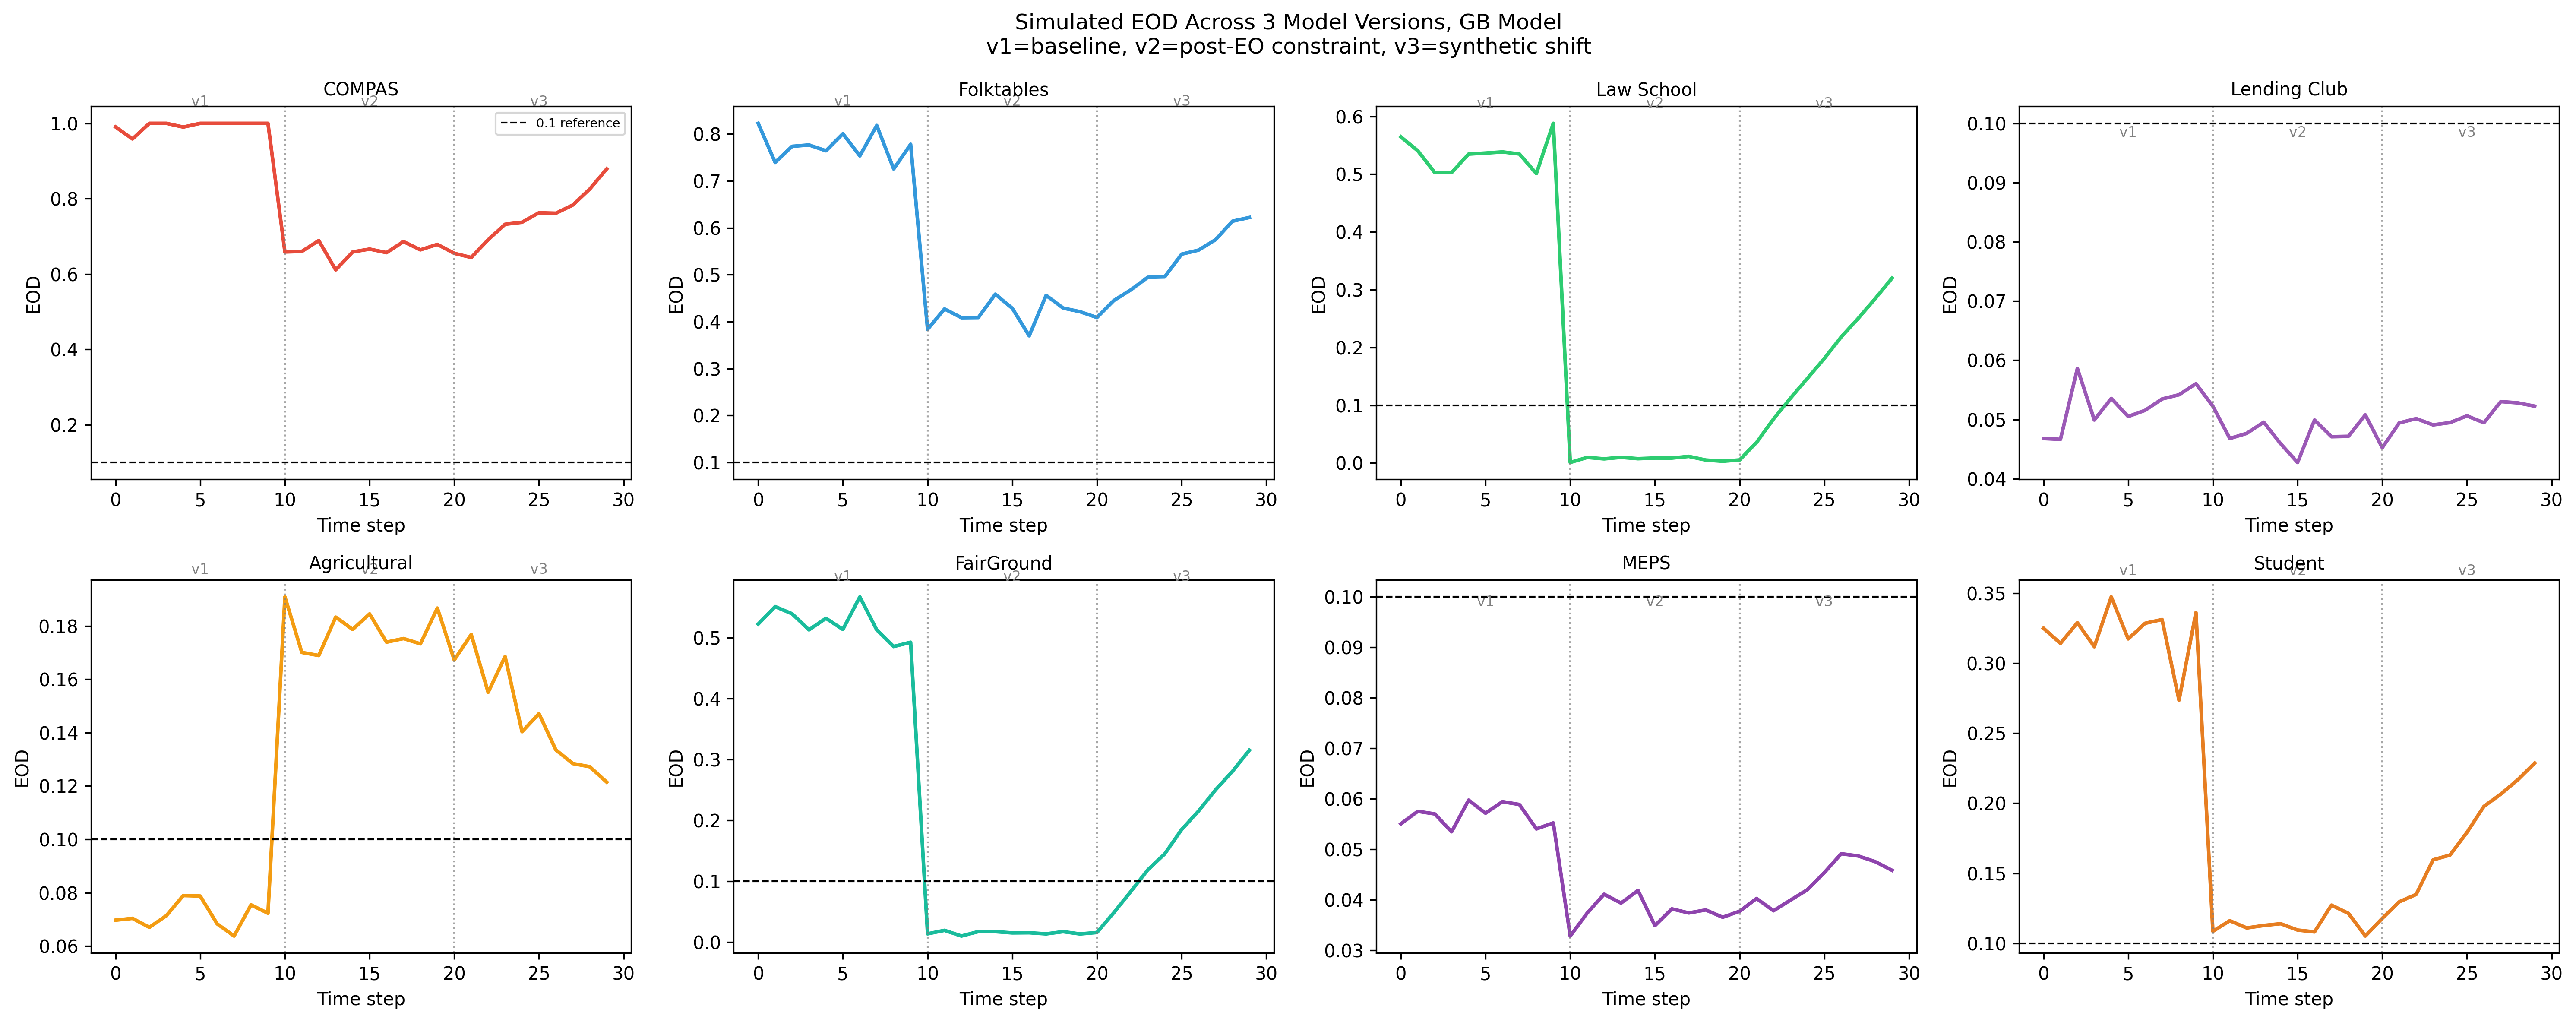

In [9]:
display(Image('figures/stage2/drift_eod_timeseries.png'))

## 8. DPD drift magnitude

How far the mean DPD under the shift sits above the deployed value, for each model and domain.

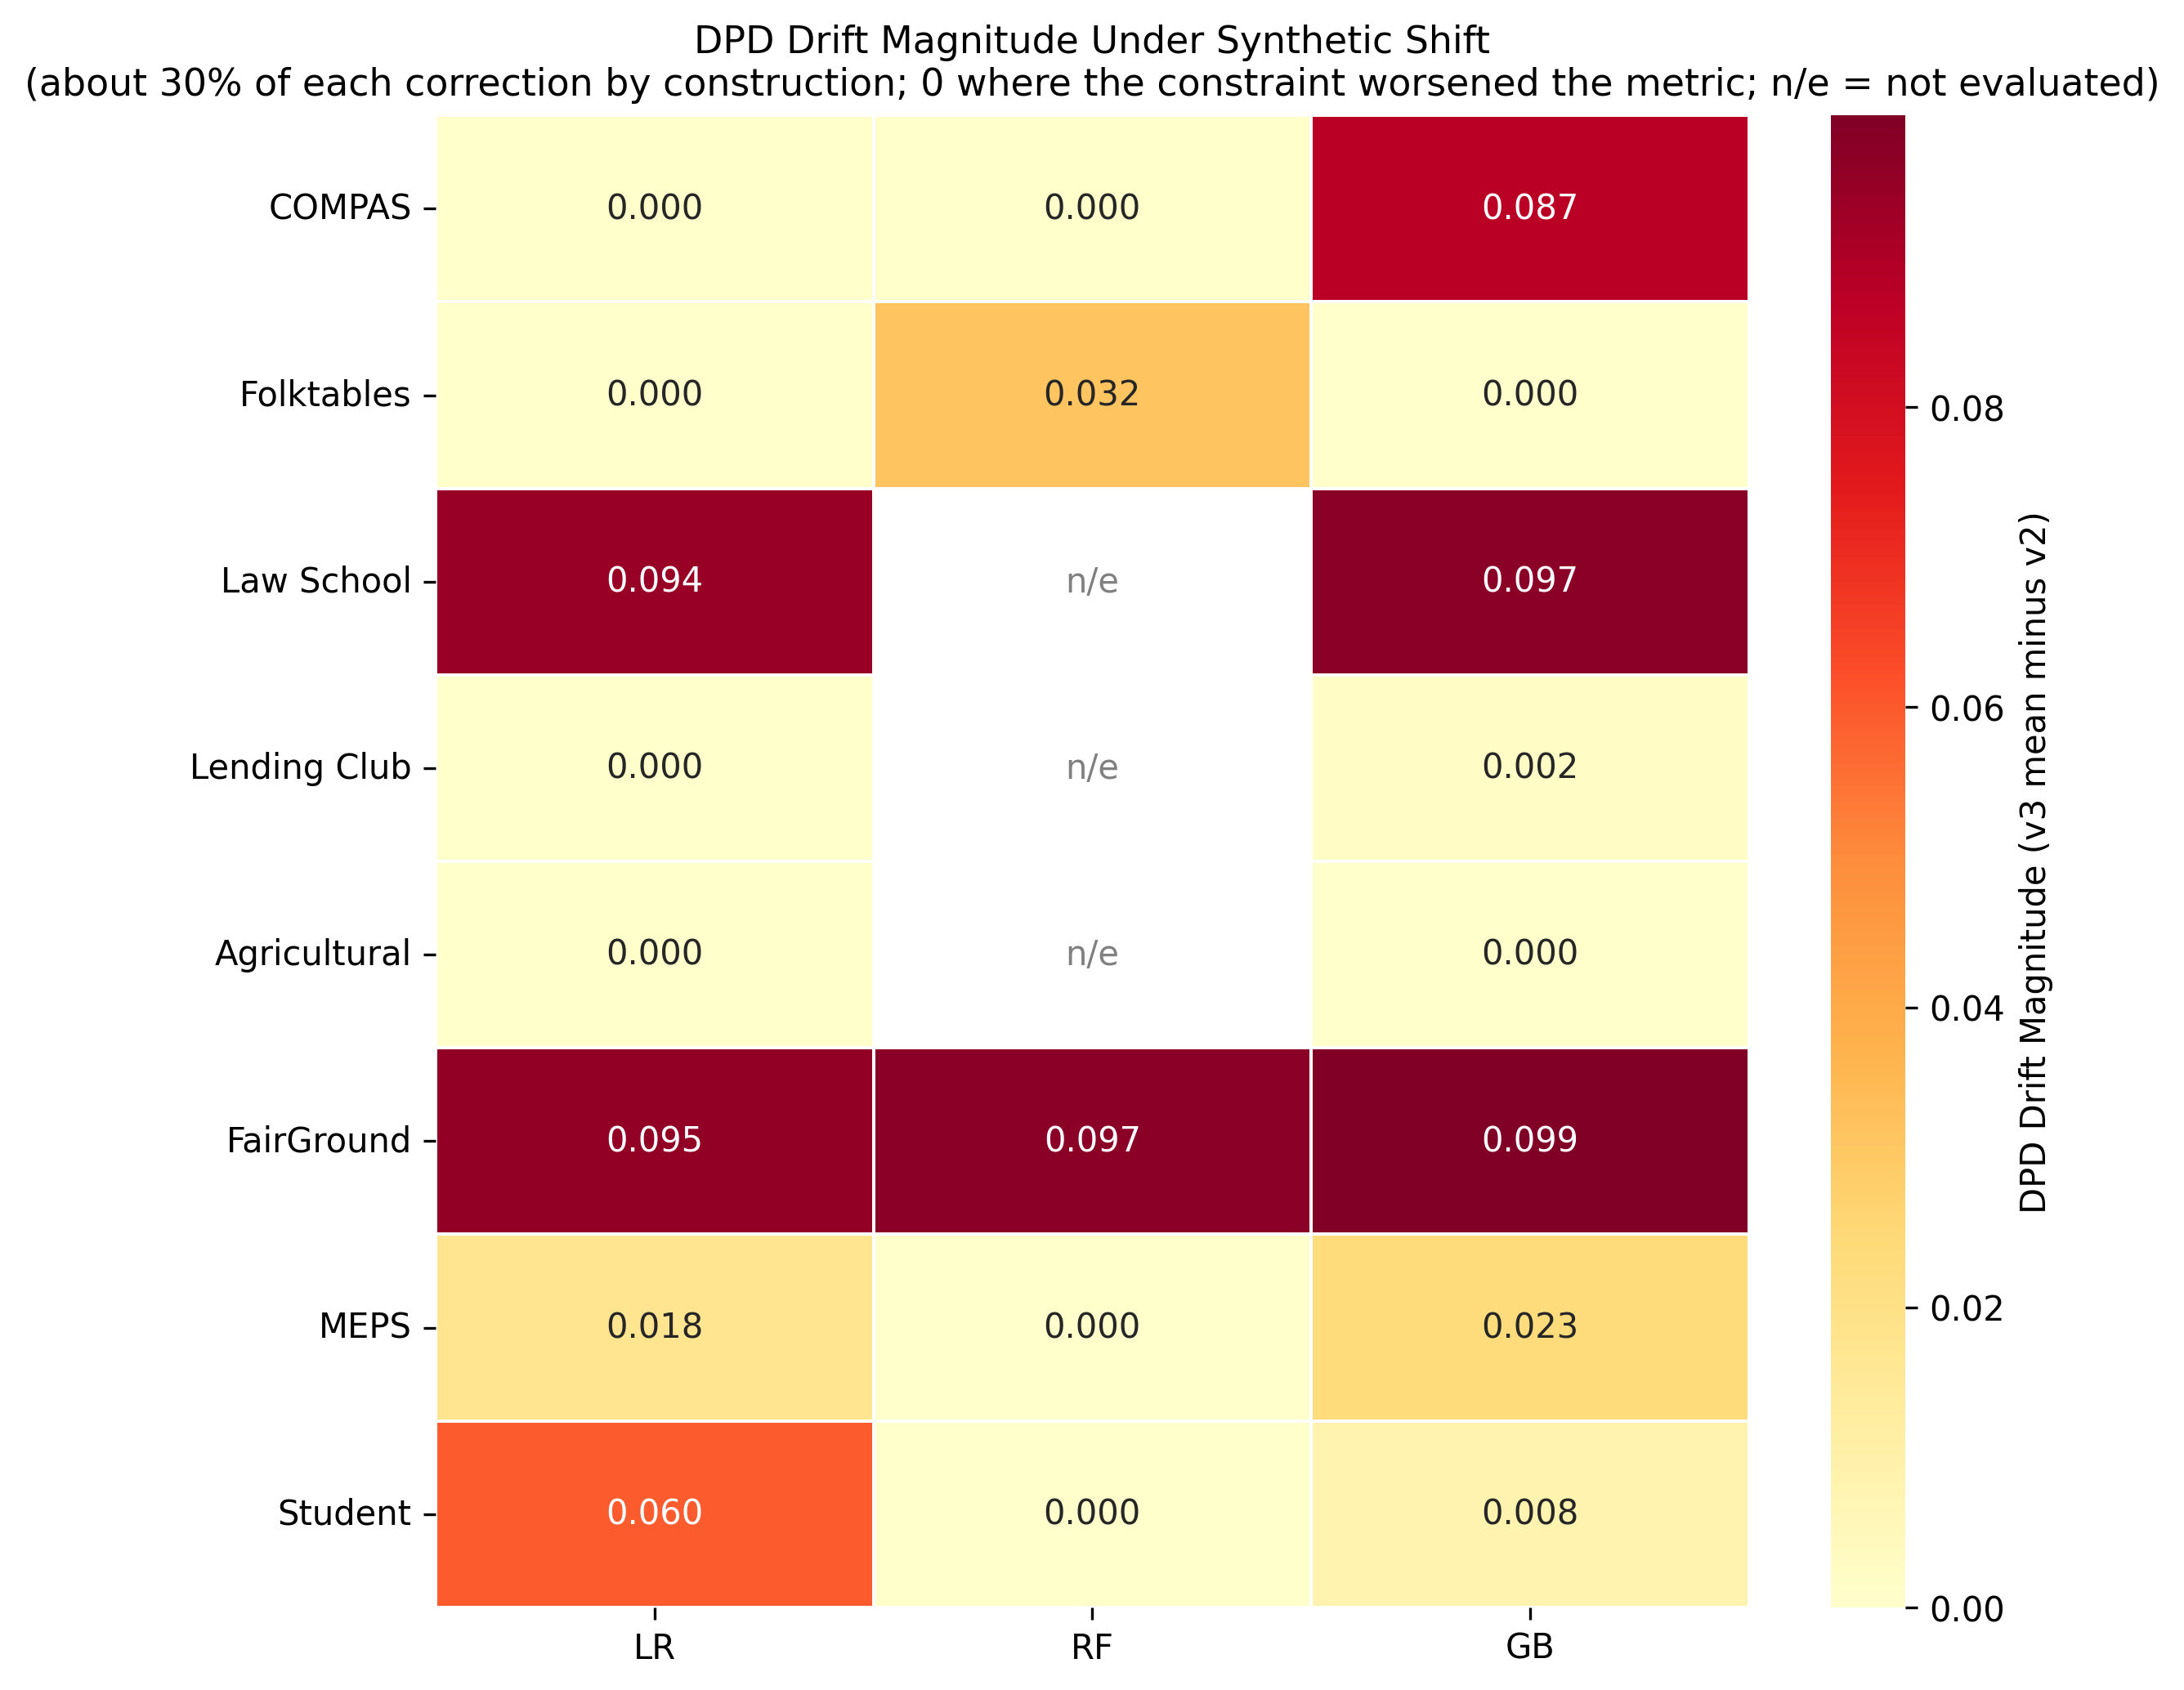

In [10]:
display(Image('figures/stage2/drift_magnitude_heatmap.png'))

## 9. EOD drift magnitude

The same drift magnitude measured on equalized odds difference.

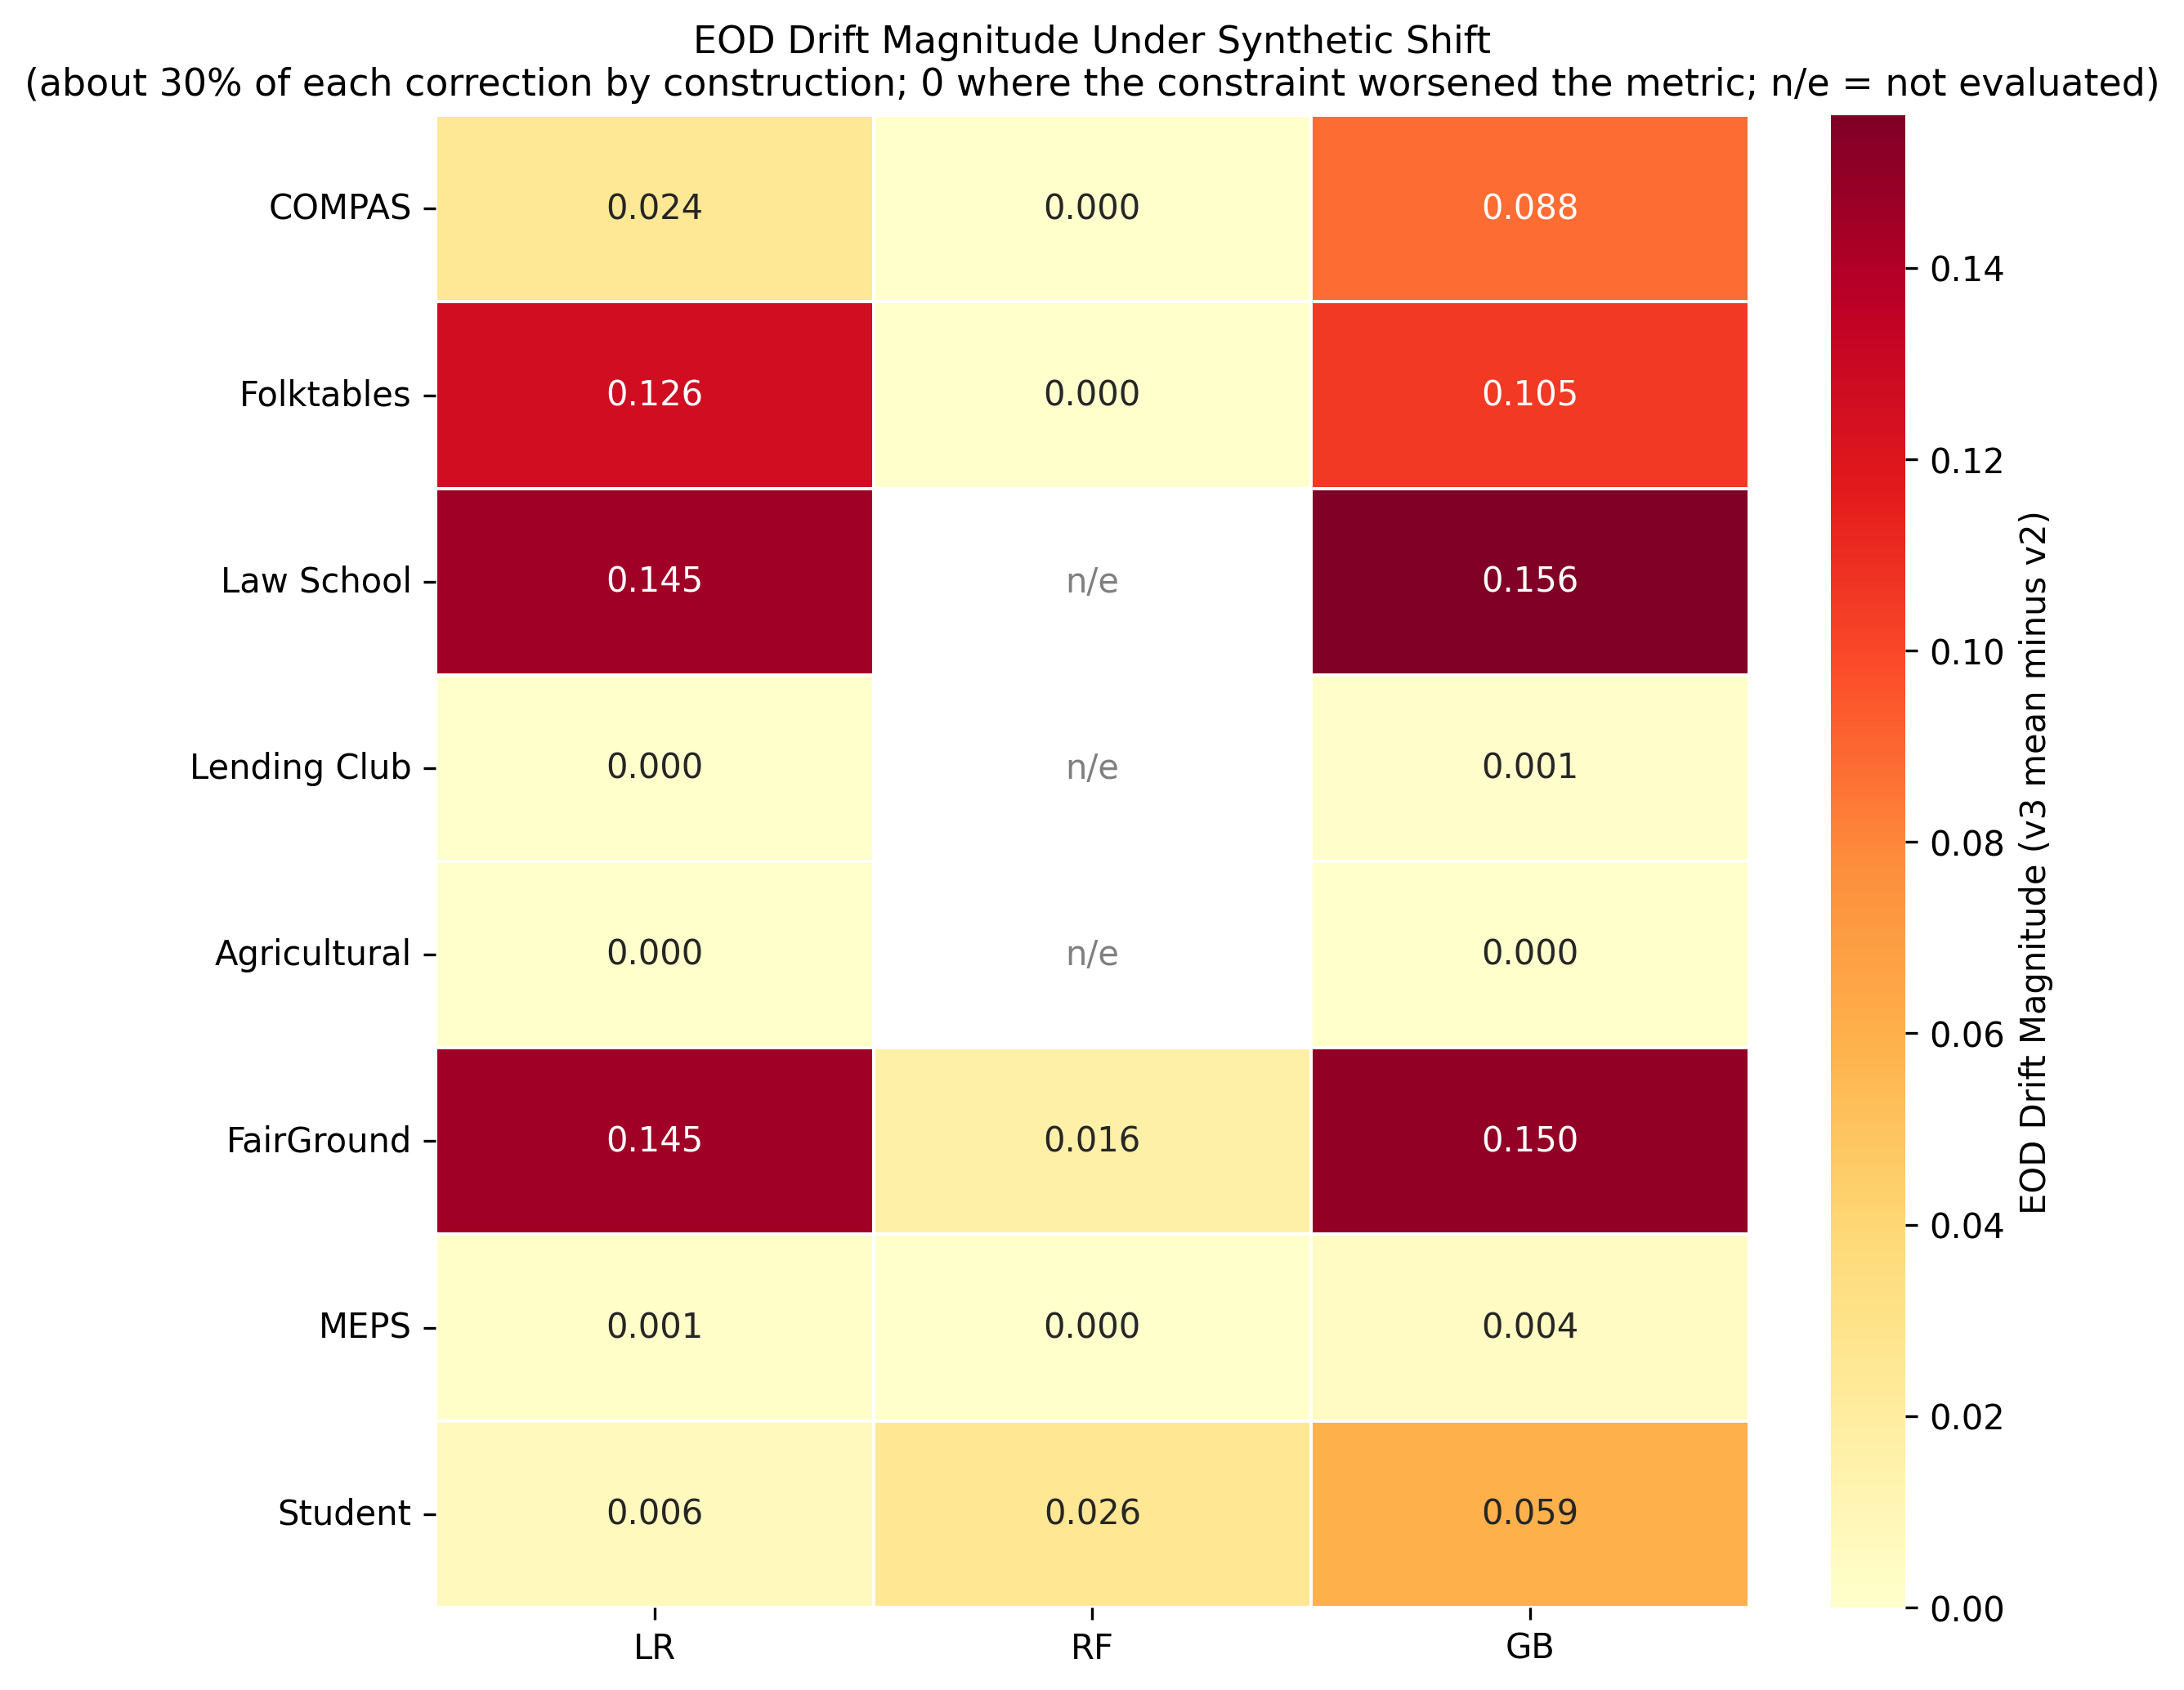

In [11]:
display(Image('figures/stage2/drift_eod_magnitude_heatmap.png'))

## Printed findings

The script's computed findings are in the output of the run cell above.